Đọc ảnh thành công


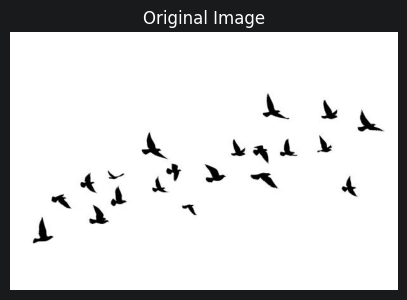

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
img = cv2.imread("img_data/bird.jpg", cv2.IMREAD_GRAYSCALE)

# kiểm tra ảnh
if img is None:
    print("Không đọc được ảnh")
else:
    print("Đọc ảnh thành công")
plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()


PHẦN A — SỬ DỤNG THƯ VIỆN OPENCV

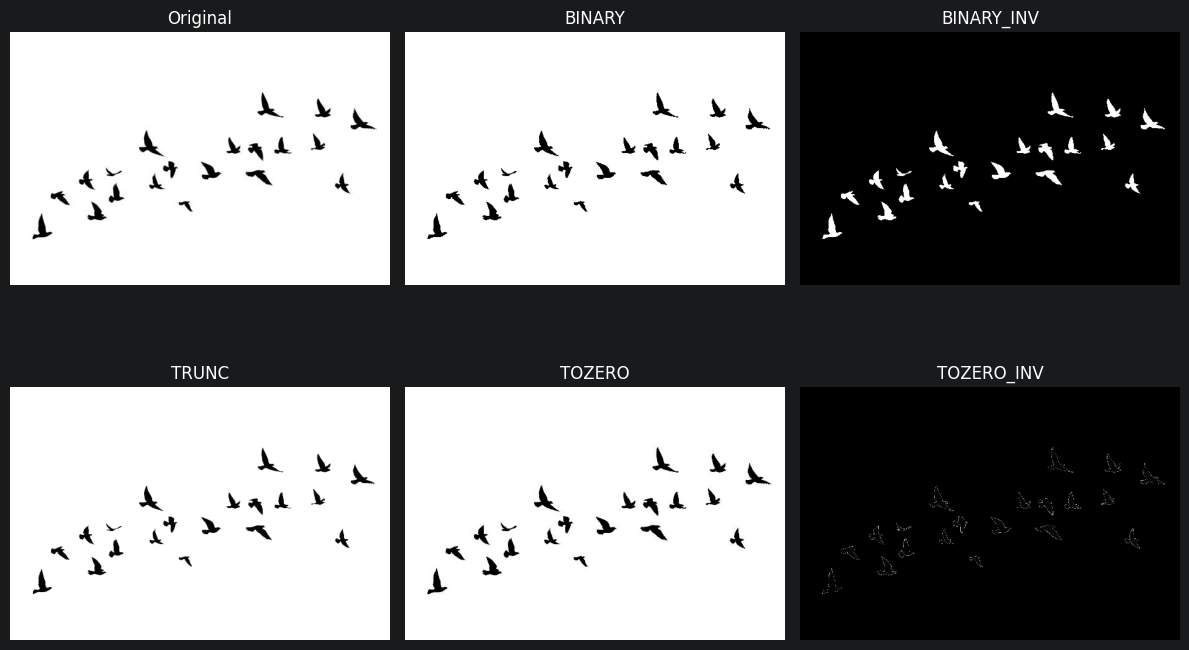

In [11]:
# 4. SIMPLE THRESHOLDING (DÙNG THƯ VIỆN)
ret, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
ret, binary_inv = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
ret, trunc = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)
ret, tozero = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)
ret, tozero_inv = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO_INV)
titles = [
    'Original',
    'BINARY',
    'BINARY_INV',
    'TRUNC',
    'TOZERO',
    'TOZERO_INV'
]

images = [
    img,
    binary,
    binary_inv,
    trunc,
    tozero,
    tozero_inv
]

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

6. ADAPTIVE THRESHOLDING

Đọc ảnh thành công


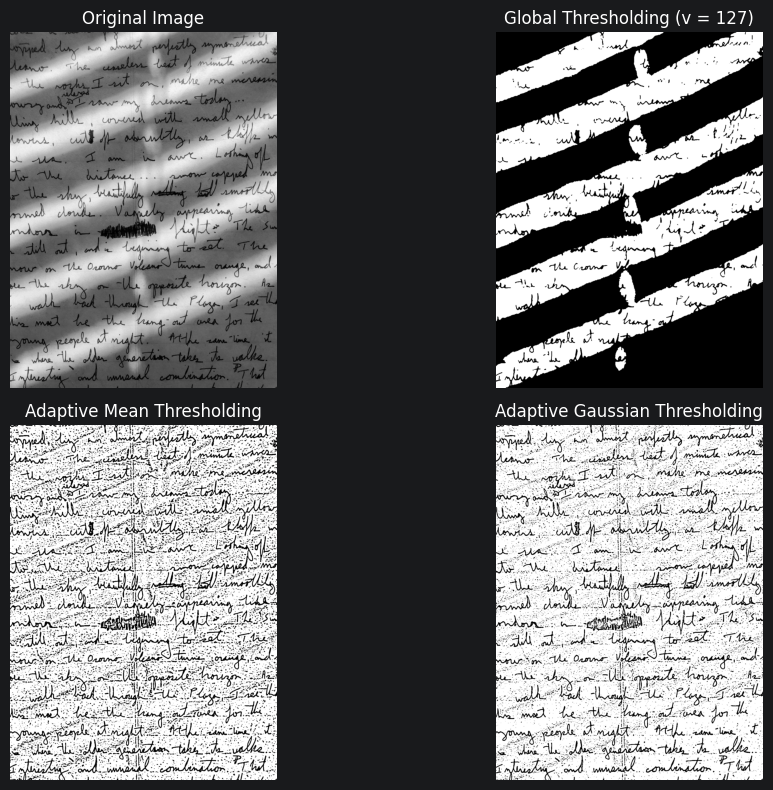

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
img = cv2.imread("img_data/anhchu.jpg", cv2.IMREAD_GRAYSCALE)

# kiểm tra ảnh
if img is None:
    print("Không đọc được ảnh")
else:
    print("Đọc ảnh thành công")
    
# Làm mờ ảnh trước để giảm nhiễu
blur = cv2.medianBlur(img, 5)

# Global Threshold
ret, global_thresh = cv2.threshold(
    blur,
    127,
    255,
    cv2.THRESH_BINARY
)

# Adaptive Mean Threshold
adaptive_mean = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

# Adaptive Gaussian Threshold
adaptive_gaussian = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)
titles = [
    'Original Image',
    'Global Thresholding (v = 127)',
    'Adaptive Mean Thresholding',
    'Adaptive Gaussian Thresholding'
]

images = [
    img,
    global_thresh,
    adaptive_mean,
    adaptive_gaussian
]

plt.figure(figsize=(12,8))

for i in range(4):

    plt.subplot(2,2,i+1)

    plt.imshow(images[i], cmap='gray')

    plt.title(titles[i])

    plt.axis('off')

plt.tight_layout()
plt.show()

8. OTSU THRESHOLDING

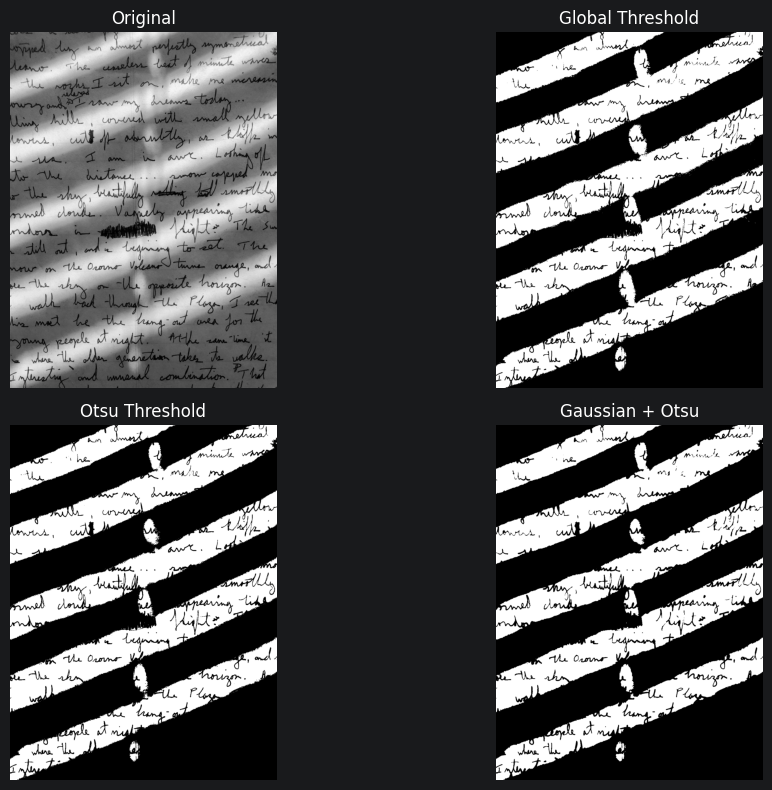

In [21]:
# Global threshold
ret1, th1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Otsu threshold
ret2, otsu = cv2.threshold(
    img,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Gaussian + Otsu
blur = cv2.GaussianBlur(img, (5,5), 0)

ret3, otsu_blur = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
titles = [
    'Original',
    'Global Threshold',
    'Otsu Threshold',
    'Gaussian + Otsu'
]

images = [
    img,
    th1,
    otsu,
    otsu_blur
]

plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

PHẦN B — KHÔNG DÙNG THƯ VIỆN (FROM SCRATCH)

10. SIMPLE THRESHOLD FROM SCRATCH

Đọc ảnh thành công


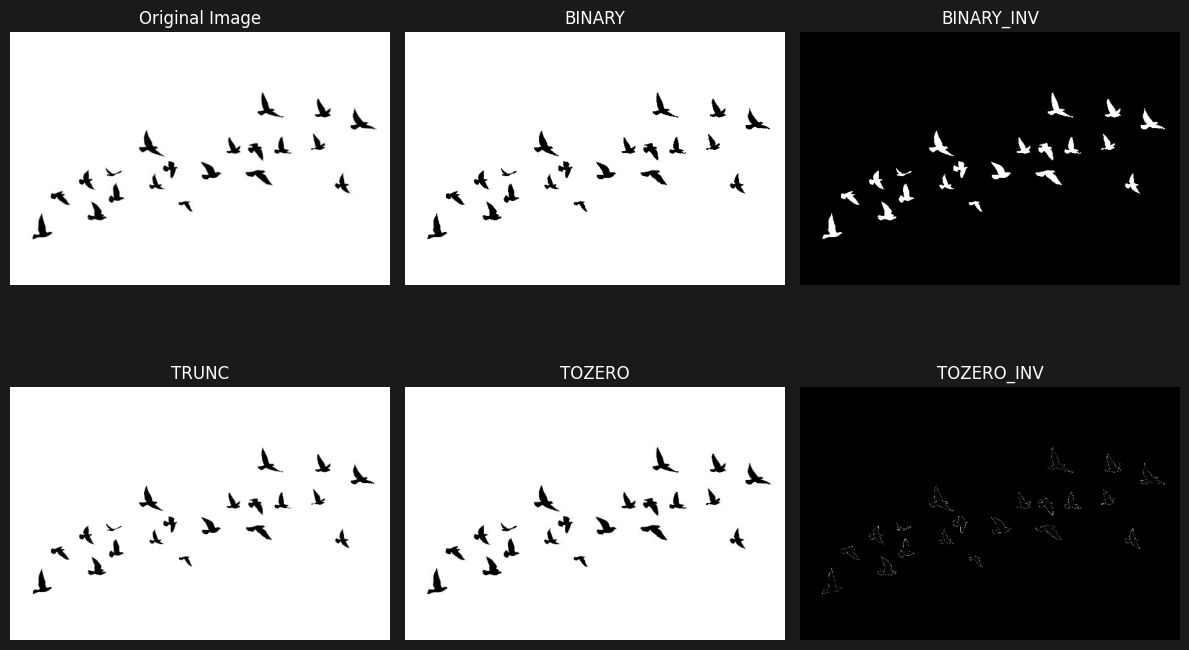

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
img = cv2.imread("img_data/bird.jpg", cv2.IMREAD_GRAYSCALE)

# kiểm tra ảnh
if img is None:
    print("Không đọc được ảnh")
else:
    print("Đọc ảnh thành công")


threshold = 127

rows, cols = img.shape

binary = np.zeros_like(img)
binary_inv = np.zeros_like(img)
trunc = np.zeros_like(img)
tozero = np.zeros_like(img)
tozero_inv = np.zeros_like(img)

for i in range(rows):

    for j in range(cols):

        pixel = img[i, j]

        # THRESH_BINARY
        if pixel > threshold:
            binary[i, j] = 255
        else:
            binary[i, j] = 0

        # THRESH_BINARY_INV
        if pixel > threshold:
            binary_inv[i, j] = 0
        else:
            binary_inv[i, j] = 255

        # THRESH_TRUNC
        if pixel > threshold:
            trunc[i, j] = threshold
        else:
            trunc[i, j] = pixel

        # THRESH_TOZERO
        if pixel > threshold:
            tozero[i, j] = pixel
        else:
            tozero[i, j] = 0

        # THRESH_TOZERO_INV
        if pixel > threshold:
            tozero_inv[i, j] = 0
        else:
            tozero_inv[i, j] = pixel

titles = [
    'Original Image',
    'BINARY',
    'BINARY_INV',
    'TRUNC',
    'TOZERO',
    'TOZERO_INV'
]

images = [
    img,
    binary,
    binary_inv,
    trunc,
    tozero,
    tozero_inv
]

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i], cmap='gray')

    plt.title(titles[i])

    plt.axis('off')

plt.tight_layout()

plt.show()

ADAPTIVE THRESHOLDING

Đọc ảnh thành công


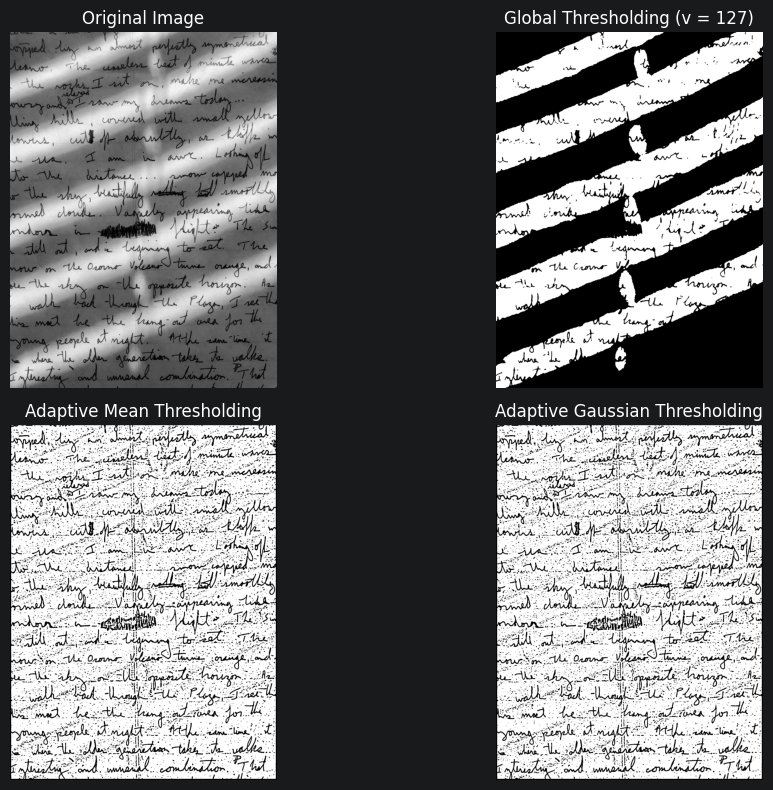

In [27]:
import cv2
import matplotlib.pyplot as plt
import os
img = cv2.imread("img_data/anhchu.jpg", cv2.IMREAD_GRAYSCALE)

# kiểm tra ảnh
if img is None:
    print("Không đọc được ảnh")
else:
    print("Đọc ảnh thành công")

img_blur = cv2.medianBlur(img, 5)

rows, cols = img_blur.shape

adaptive_mean = np.zeros_like(img_blur)

adaptive_gaussian = np.zeros_like(img_blur)

global_threshold = np.zeros_like(img_blur)

block_size = 11
C = 2

pad = block_size // 2

# Global Threshold
for i in range(rows):

    for j in range(cols):

        if img_blur[i, j] > 127:
            global_threshold[i, j] = 255
        else:
            global_threshold[i, j] = 0


# Adaptive Mean Threshold
for i in range(pad, rows-pad):

    for j in range(pad, cols-pad):

        region = img_blur[
            i-pad:i+pad+1,
            j-pad:j+pad+1
        ]

        mean_value = np.mean(region)

        threshold_value = mean_value - C

        if img_blur[i, j] > threshold_value:
            adaptive_mean[i, j] = 255
        else:
            adaptive_mean[i, j] = 0


# Adaptive Gaussian Threshold
for i in range(pad, rows-pad):

    for j in range(pad, cols-pad):

        region = img_blur[
            i-pad:i+pad+1,
            j-pad:j+pad+1
        ]

        gaussian = cv2.GaussianBlur(region, (11,11), 0)

        gaussian_mean = np.mean(gaussian)

        threshold_value = gaussian_mean - C

        if img_blur[i, j] > threshold_value:
            adaptive_gaussian[i, j] = 255
        else:
            adaptive_gaussian[i, j] = 0


titles = [
    'Original Image',
    'Global Thresholding (v = 127)',
    'Adaptive Mean Thresholding',
    'Adaptive Gaussian Thresholding'
]

images = [
    img,
    global_threshold,
    adaptive_mean,
    adaptive_gaussian
]

plt.figure(figsize=(12,8))

for i in range(4):

    plt.subplot(2,2,i+1)

    plt.imshow(images[i], cmap='gray')

    plt.title(titles[i])

    plt.axis('off')

plt.tight_layout()

plt.show()

OTSU'S BINARIZATION

Best Threshold = 140


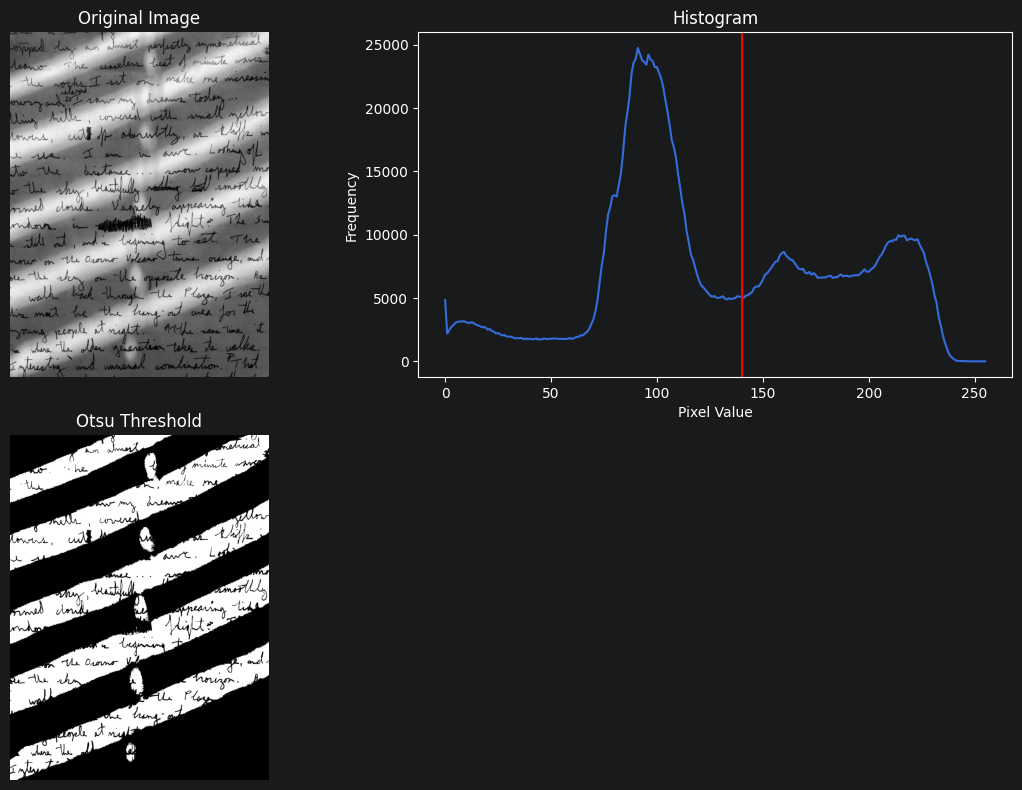

In [28]:

rows, cols = img.shape

# Tính histogram
histogram = np.zeros(256)

for i in range(rows):

    for j in range(cols):

        pixel = img[i, j]

        histogram[pixel] += 1


# Chuẩn hóa histogram
hist_norm = histogram / histogram.sum()

# Tính cumulative sum
Q = hist_norm.cumsum()

bins = np.arange(256)

fn_min = np.inf

best_threshold = -1

# Tìm threshold tối ưu
for t in range(1, 256):

    # class 1
    p1 = hist_norm[:t]

    # class 2
    p2 = hist_norm[t:]

    # cumulative probability
    q1 = Q[t]

    q2 = Q[255] - Q[t]

    if q1 < 1e-6 or q2 < 1e-6:
        continue

    # mean
    b1 = bins[:t]
    b2 = bins[t:]

    m1 = np.sum(p1 * b1) / q1

    m2 = np.sum(p2 * b2) / q2

    # variance
    v1 = np.sum(((b1 - m1) ** 2) * p1) / q1

    v2 = np.sum(((b2 - m2) ** 2) * p2) / q2

    # within-class variance
    fn = v1 * q1 + v2 * q2

    if fn < fn_min:

        fn_min = fn

        best_threshold = t


print("Best Threshold =", best_threshold)


# Áp dụng threshold
otsu_img = np.zeros_like(img)

for i in range(rows):

    for j in range(cols):

        if img[i, j] > best_threshold:
            otsu_img[i, j] = 255
        else:
            otsu_img[i, j] = 0


# Hiển thị kết quả
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.plot(histogram)
plt.axvline(best_threshold, color='r')
plt.title("Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.subplot(2,2,3)
plt.imshow(otsu_img, cmap='gray')
plt.title("Otsu Threshold")
plt.axis('off')

plt.tight_layout()

plt.show()

HOW DOES OTSU'S BINARIZATION WORK?

Đọc ảnh thành công
Best Threshold = 140


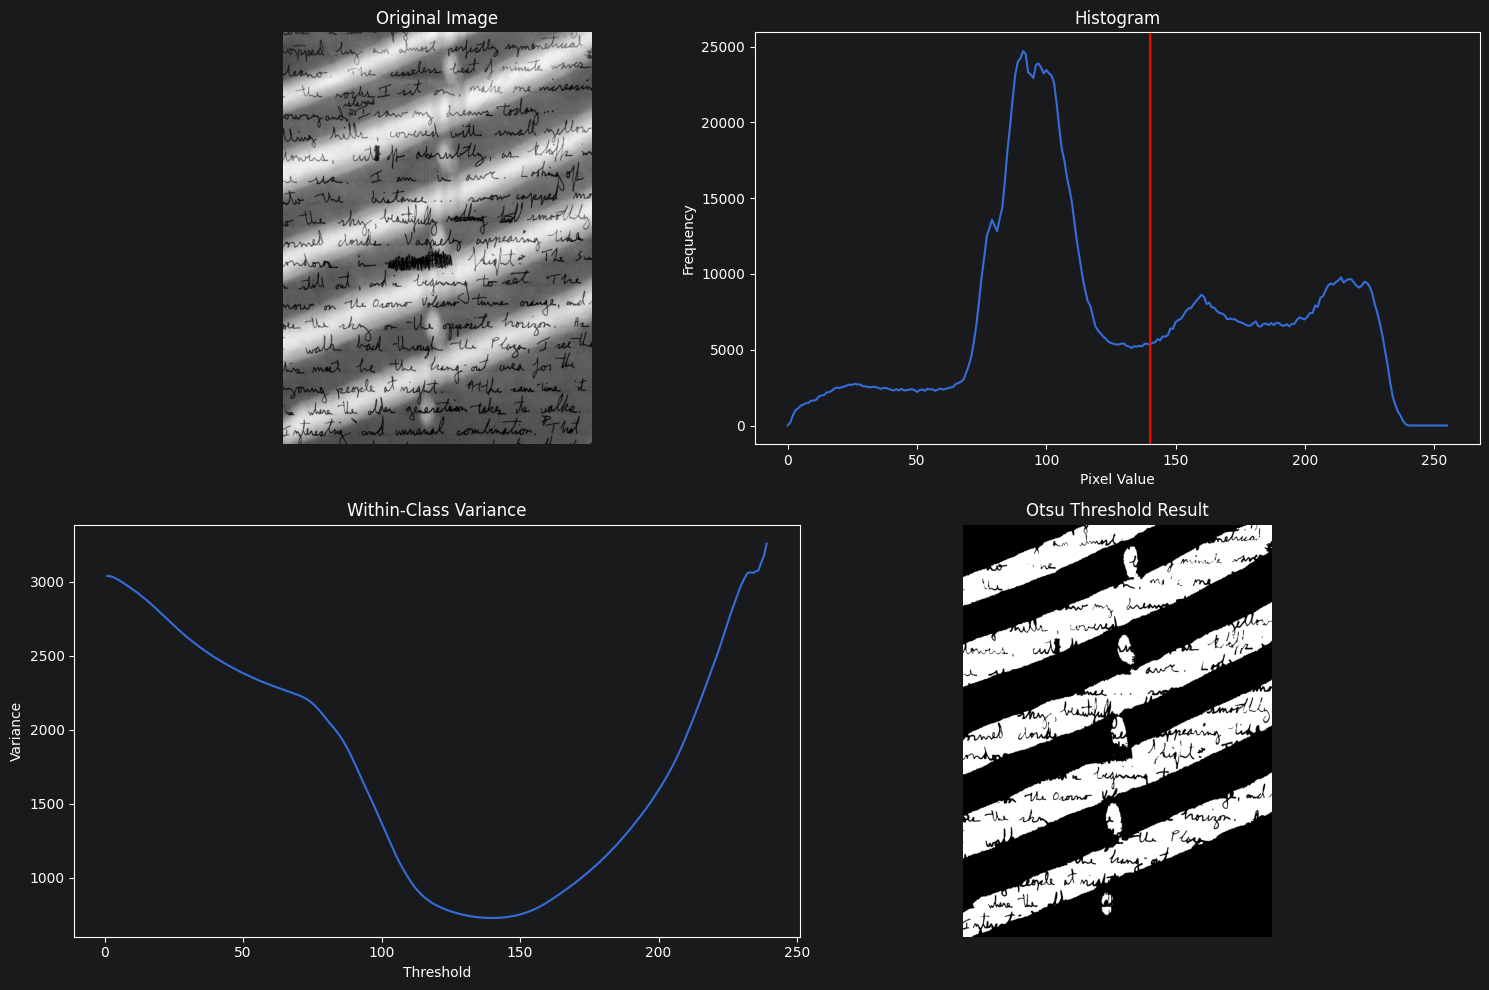

In [31]:
import cv2
import matplotlib.pyplot as plt
import os
img = cv2.imread("img_data/anhchu.jpg", cv2.IMREAD_GRAYSCALE)

# kiểm tra ảnh
if img is None:
    print("Không đọc được ảnh")
else:
    print("Đọc ảnh thành công")

# LÀM MỜ ẢNH GIẢM NHIỄU
blur = cv2.GaussianBlur(img, (5,5), 0)

# TÍNH HISTOGRAM TỪ ĐẦU

rows, cols = blur.shape
histogram = np.zeros(256)

for i in range(rows):

    for j in range(cols):

        pixel = blur[i, j]

        histogram[pixel] += 1

# NORMALIZED HISTOGRAM
hist_norm = histogram / histogram.sum()
# CUMULATIVE SUM
Q = hist_norm.cumsum()

# OTSU ALGORITHM
bins = np.arange(256)
fn_min = np.inf
best_threshold = -1
variance_values = []
threshold_values = []

for t in range(1, 256):

    # CLASS 1
    p1 = hist_norm[:t]

    # CLASS 2
    p2 = hist_norm[t:]

    # CLASS PROBABILITIES
    q1 = Q[t]

    q2 = Q[255] - Q[t]

    if q1 < 1e-6 or q2 < 1e-6:
        continue

    # MEAN
    b1 = bins[:t]
    b2 = bins[t:]
    m1 = np.sum(p1 * b1) / q1
    m2 = np.sum(p2 * b2) / q2

    # VARIANCE

    v1 = np.sum(((b1 - m1) ** 2) * p1) / q1

    v2 = np.sum(((b2 - m2) ** 2) * p2) / q2

    # WITHIN CLASS VARIANCE
    fn = v1 * q1 + v2 * q2
    variance_values.append(fn)
    threshold_values.append(t)

    # FIND MINIMUM VARIANCE
    if fn < fn_min:

        fn_min = fn

        best_threshold = t


print("Best Threshold =", best_threshold)

# APPLY OTSU THRESHOLD

otsu_img = np.zeros_like(blur)

for i in range(rows):

    for j in range(cols):

        if blur[i, j] > best_threshold:

            otsu_img[i, j] = 255

        else:

            otsu_img[i, j] = 0

# HIỂN THỊ KẾT QUẢ

plt.figure(figsize=(15,10))

# Original Image
plt.subplot(2,2,1)

plt.imshow(img, cmap='gray')

plt.title("Original Image")

plt.axis('off')


# Histogram
plt.subplot(2,2,2)

plt.plot(histogram)

plt.axvline(best_threshold, color='r')

plt.title("Histogram")

plt.xlabel("Pixel Value")

plt.ylabel("Frequency")


# Variance Graph
plt.subplot(2,2,3)

plt.plot(threshold_values, variance_values)

plt.title("Within-Class Variance")

plt.xlabel("Threshold")

plt.ylabel("Variance")


# Otsu Result
plt.subplot(2,2,4)

plt.imshow(otsu_img, cmap='gray')

plt.title("Otsu Threshold Result")

plt.axis('off')


plt.tight_layout()

plt.show()